In [1]:
import cv2
import os
import torch

from matplotlib import pyplot as plt
from Depth_Anything_V2.depth_anything_v2.dpt import DepthAnythingV2

/opt/conda/envs/evtOcc_mono/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
xFormers not available
xFormers not available


In [2]:

DEVICE = 'cuda:4' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
    'vitg': {'encoder': 'vitg', 'features': 384, 'out_channels': [1536, 1536, 1536, 1536]}
}

#encoder = 'vitl' # or 'vits', 'vitb', 'vitg'
encoder = 'vitb'

model = DepthAnythingV2(**model_configs[encoder])
model.load_state_dict(torch.load(f'checkpoints/depth_anything_v2_{encoder}.pth', map_location='cuda:4'))
model = model.to(DEVICE).eval()

In [50]:
root_fpath = '/root/dev/data/dataset/SemanticKITTI/dataset/sequences/00/image_2'
evt_root_fpath = '/root/dev/data/dataset/SemanticKITTI/event_bin3_onoff_noNorm/00/image_2'

fname = os.listdir(root_fpath)[150]
fid = fname.split('.')[0]
fpath = os.path.join(root_fpath, fname)

evt_fname = os.listdir(evt_root_fpath)[0]
evt_fpath = os.path.join(evt_root_fpath, f'{fid}.npy')

fname, "\n", fpath, "\n", evt_fname, "\n", evt_fpath

('001957.png',
 '\n',
 '/root/dev/data/dataset/SemanticKITTI/dataset/sequences/00/image_2/001957.png',
 '\n',
 '000001.npy',
 '\n',
 '/root/dev/data/dataset/SemanticKITTI/event_bin3_onoff_noNorm/00/image_2/001957.npy')

In [51]:
raw_img = cv2.imread(fpath)[:, :, ::-1].copy() # why copy does work?
depth = model.infer_image(raw_img)

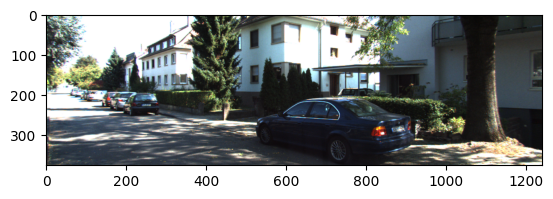

In [52]:
plt.imshow(raw_img)

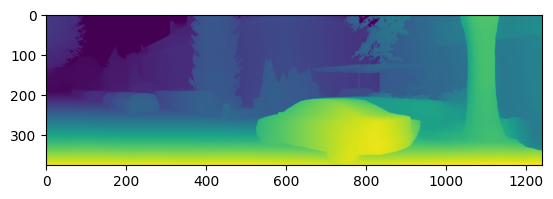

In [53]:
plt.imshow(depth)

In [97]:
import numpy as np

evt = np.load(evt_fpath, allow_pickle=True)
evt = evt.transpose(1, 2, 0)  # (C, H, W) → (H, W, C)
evt = evt.copy() 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


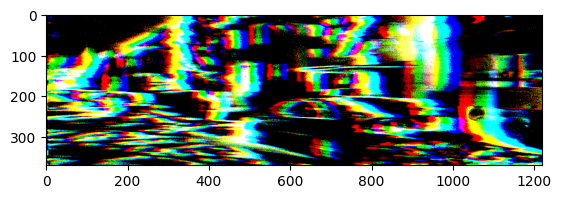

In [66]:
plt.imshow(evt)

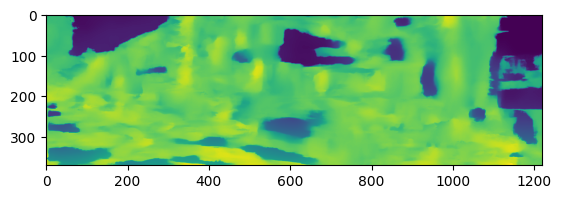

In [67]:
depth_ = model.infer_image(evt * 255.0)

plt.imshow(depth_)

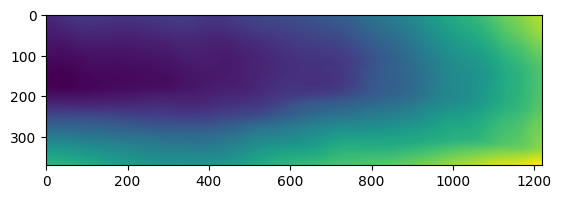

In [80]:
depth_ = model.infer_image(evt)

plt.imshow(depth_)

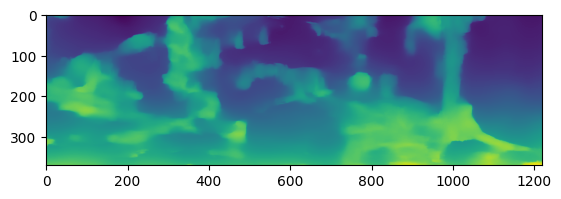

In [81]:
a = evt[:,:,0] * 255
b = np.repeat(a[:, :, np.newaxis], 3, axis=2)

depth_ = model.infer_image(b)

plt.imshow(depth_)

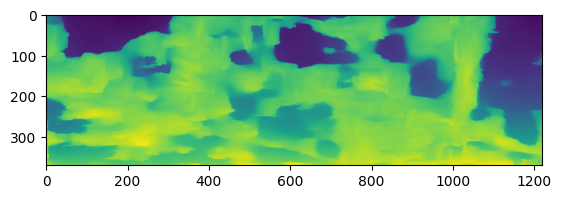

In [82]:
a = evt[:,:,1] * 255
b = np.repeat(a[:, :, np.newaxis], 3, axis=2)

depth_ = model.infer_image(b)

plt.imshow(depth_)

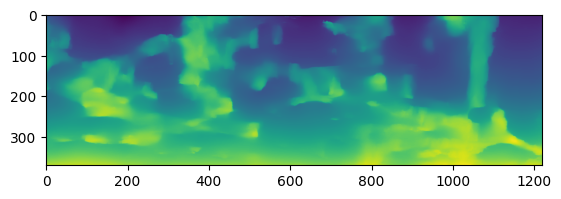

In [83]:
a = evt[:,:,2] * 255
b = np.repeat(a[:, :, np.newaxis], 3, axis=2)

depth_ = model.infer_image(b)

plt.imshow(depth_)

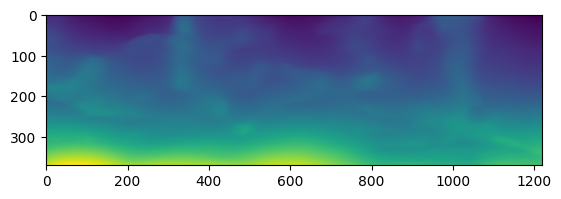

In [84]:
depth_ = model.infer_image(evt * 125.0)

plt.imshow(depth_)

In [ ]:
depth_ = model.infer_image(evt * 255.0)

plt.imshow(depth_)

In [ ]:
np.median(evt, axis=)

array([[-0.4469976 , -0.145527  , -0.8082108 , ...,  0.        ,
        -0.3762255 ,  0.        ],
       [-1.737745  , -0.9745711 , -0.25      , ...,  0.        ,
         0.        ,  0.        ],
       [-0.2227329 , -0.375     , -0.68443626, ...,  0.        ,
         0.        , -0.47150734],
       ...,
       [ 3.6930149 ,  3.2071078 ,  2.1194854 , ...,  0.56801474,
         1.9466912 ,  1.9518995 ],
       [ 2.0732229 ,  3.0523894 ,  1.8927696 , ...,  1.7521447 ,
         0.9206495 ,  0.93474245],
       [ 1.4488357 ,  2.24663   ,  2.90962   , ...,  0.7941177 ,
         1.3572303 ,  4.1179533 ]], dtype=float32)

In [ ]:
depth_ = model.infer_image(evt * 255.0)

plt.imshow(depth_)

In [88]:
filtered_vals.shape

(526621,)

-21.170649

In [104]:
np.mean(median_vals, axis=0)

array([[-0.00448836]], dtype=float32)

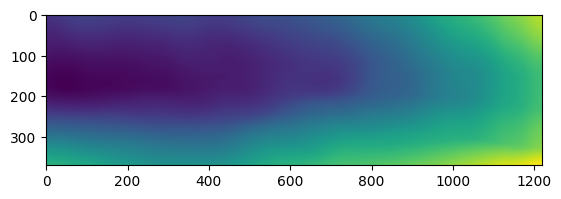

In [100]:
evt_ = evt.copy()

median_vals = np.median(evt_, axis=(1, 2), keepdims=True)  # shape: (3,1,1)

# 예: median ± tolerance 내의 값만 추출
tolerance = 10.0
mask = np.abs(evt_ - median_vals) <= tolerance

# 값만 뽑기 (1D 배열로 flatten)
evt_[mask == False] = 0
depth_ = model.infer_image(evt_)

plt.imshow(depth_)

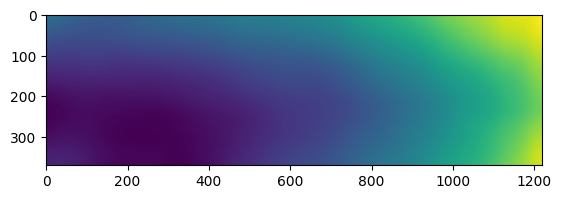

In [105]:
evt_ = evt.copy()

evt_[evt_ == 0.] = 255.
depth_ = model.infer_image(evt_)

plt.imshow(depth_)

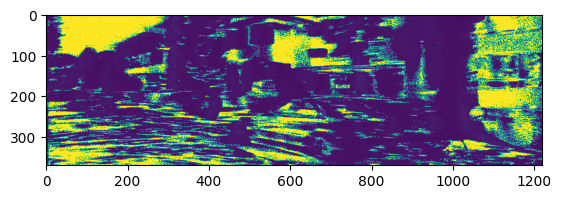

In [ ]:
plt.imshow(evt_[:,:,0])

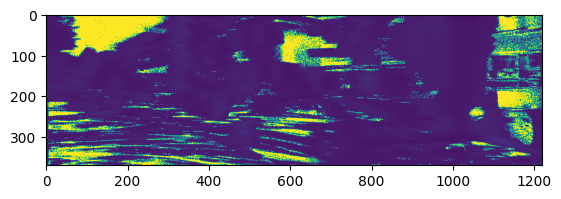

In [108]:
plt.imshow(evt_[:,:,1])

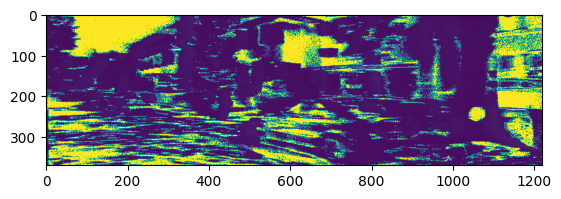

In [109]:
plt.imshow(evt_[:,:,2])

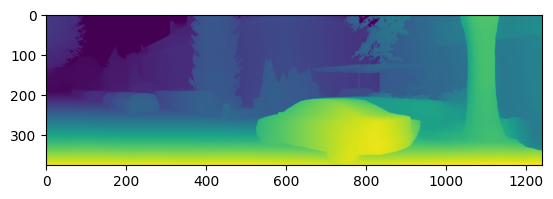

In [58]:
plt.imshow(depth)

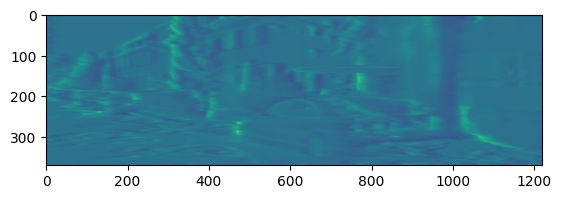

In [60]:
plt.imshow(evt[:,:,0])

In [62]:
np.min(evt)

-21.170649